### Import the Libraries and Load the Data

In [ ]:
# Import the Libraries & Load the Dataset
import numpy as np
import pandas as pd
import seaborn as sns
import os
ignore_warnings = True

RAW_DATA_PATH = os.path.join(r"C:\Users\nikun\Documents\Demand Forecasting\data", "raw")
PROCESSED_DATA_PATH = os.path.join(r"C:\Users\nikun\Documents\Demand Forecasting\data", "processed")

train_df = pd.read_csv(os.path.join(RAW_DATA_PATH, "train.csv"))
test_df = pd.read_csv(os.path.join(RAW_DATA_PATH, "test.csv"))
store_df = pd.read_csv(os.path.join(RAW_DATA_PATH, "store.csv"))

C:\Users\nikun\AppData\Local\Temp\ipykernel_7900\3434959561.py:11: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(os.path.join(RAW_DATA_PATH, "train.csv"))


In [48]:
# Display the first few rows of Train DataFrame
print(train_df.head())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  


### Train Data - Exploratory Data Analysis

In [49]:
# Display the General Information about Train DataFrame
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
None


In [50]:
# Check for Missing Values in Train DataFrame
missing_values = train_df.isnull().sum()
print("Missing Values per Column in train_df")
print(missing_values)

total_missing = train_df.isnull().sum().sum()
print(f"\nTotal Missing Values in train_df : {total_missing}")

# Check for Duplicates in Train DataFrame
duplicates = train_df.duplicated().sum()
print(f"Total Duplicates in train_df : {duplicates}")

Missing Values per Column in train_df
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Total Missing Values in train_df : 0
Total Duplicates in train_df : 0


In [51]:
# Display Five Number Summary for Sales Column
minimum, Q1, median, Q3, maximum = train_df['Sales'].quantile([0, 0.25, 0.5, 0.75, 1])
print("Five Number Summary for Sales Column")
print(f"Minimum : {minimum} \nQ1 : {Q1} \nMedian : {median} \nQ3 : {Q3} \nMaximum : {maximum}")

# Display Upper and Lower Bound for Sales Column
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\nUpper and Lower Bound for Sales Column")
print(f"Lower Bound : {lower_bound} \nUpper Bound : {upper_bound}")

# Display the Outliers in Sales Column
lower_outliers = train_df[(train_df['Sales'] < lower_bound)]
upper_outliers = train_df[(train_df['Sales'] > upper_bound)]
print(f"\nNumber of Outliers in Sales Column")
print(f"Lower Outliers : {lower_outliers.shape[0]} \nUpper Outliers : {upper_outliers.shape[0]}")

Five Number Summary for Sales Column
Minimum : 0.0 
Q1 : 3727.0 
Median : 5744.0 
Q3 : 7856.0 
Maximum : 41551.0

Upper and Lower Bound for Sales Column
Lower Bound : -2466.5 
Upper Bound : 14049.5

Number of Outliers in Sales Column
Lower Outliers : 0 
Upper Outliers : 26694


In [52]:
# Check for Sales where Store is Closed
closed_store_sales = train_df[(train_df['Open'] == 0) & (train_df['Sales'] > 0)]
print(f"Number of Instances where Store is Closed but Sales Exist : {closed_store_sales.shape[0]}")

Number of Instances where Store is Closed but Sales Exist : 0


<Axes: ylabel='Sales'>

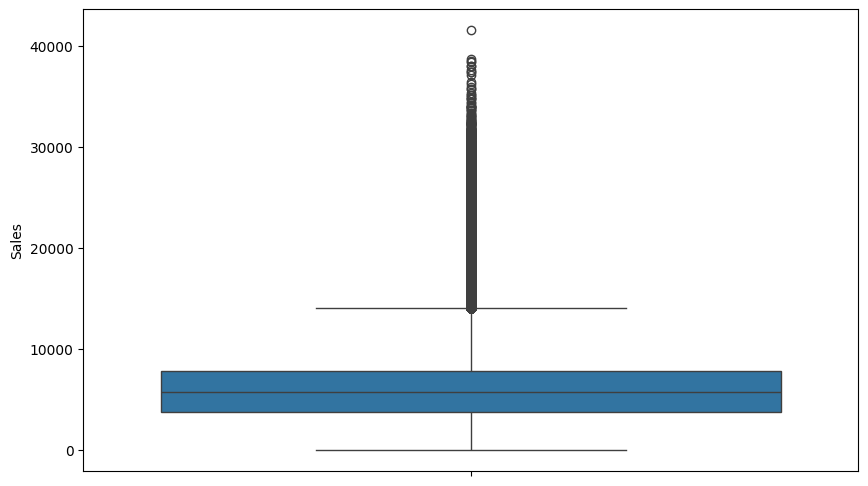

In [53]:
# Display BoxPlot for Sales Column
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(y=train_df['Sales'])

Text(0.5, 1.0, 'Histogram of Sales')

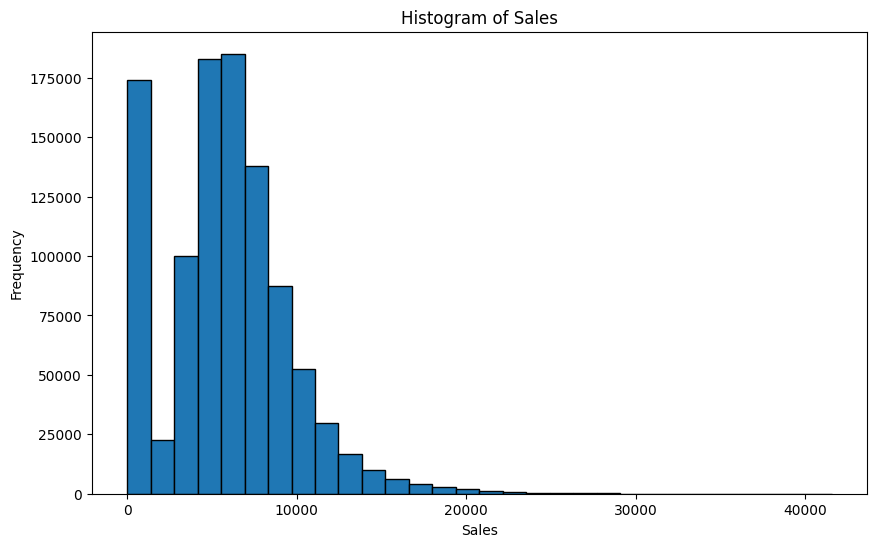

In [54]:
# Display Histogram for Sales Column
plt.figure(figsize=(10, 6))
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.hist(train_df['Sales'], bins=30, edgecolor='k')
plt.title('Histogram of Sales')

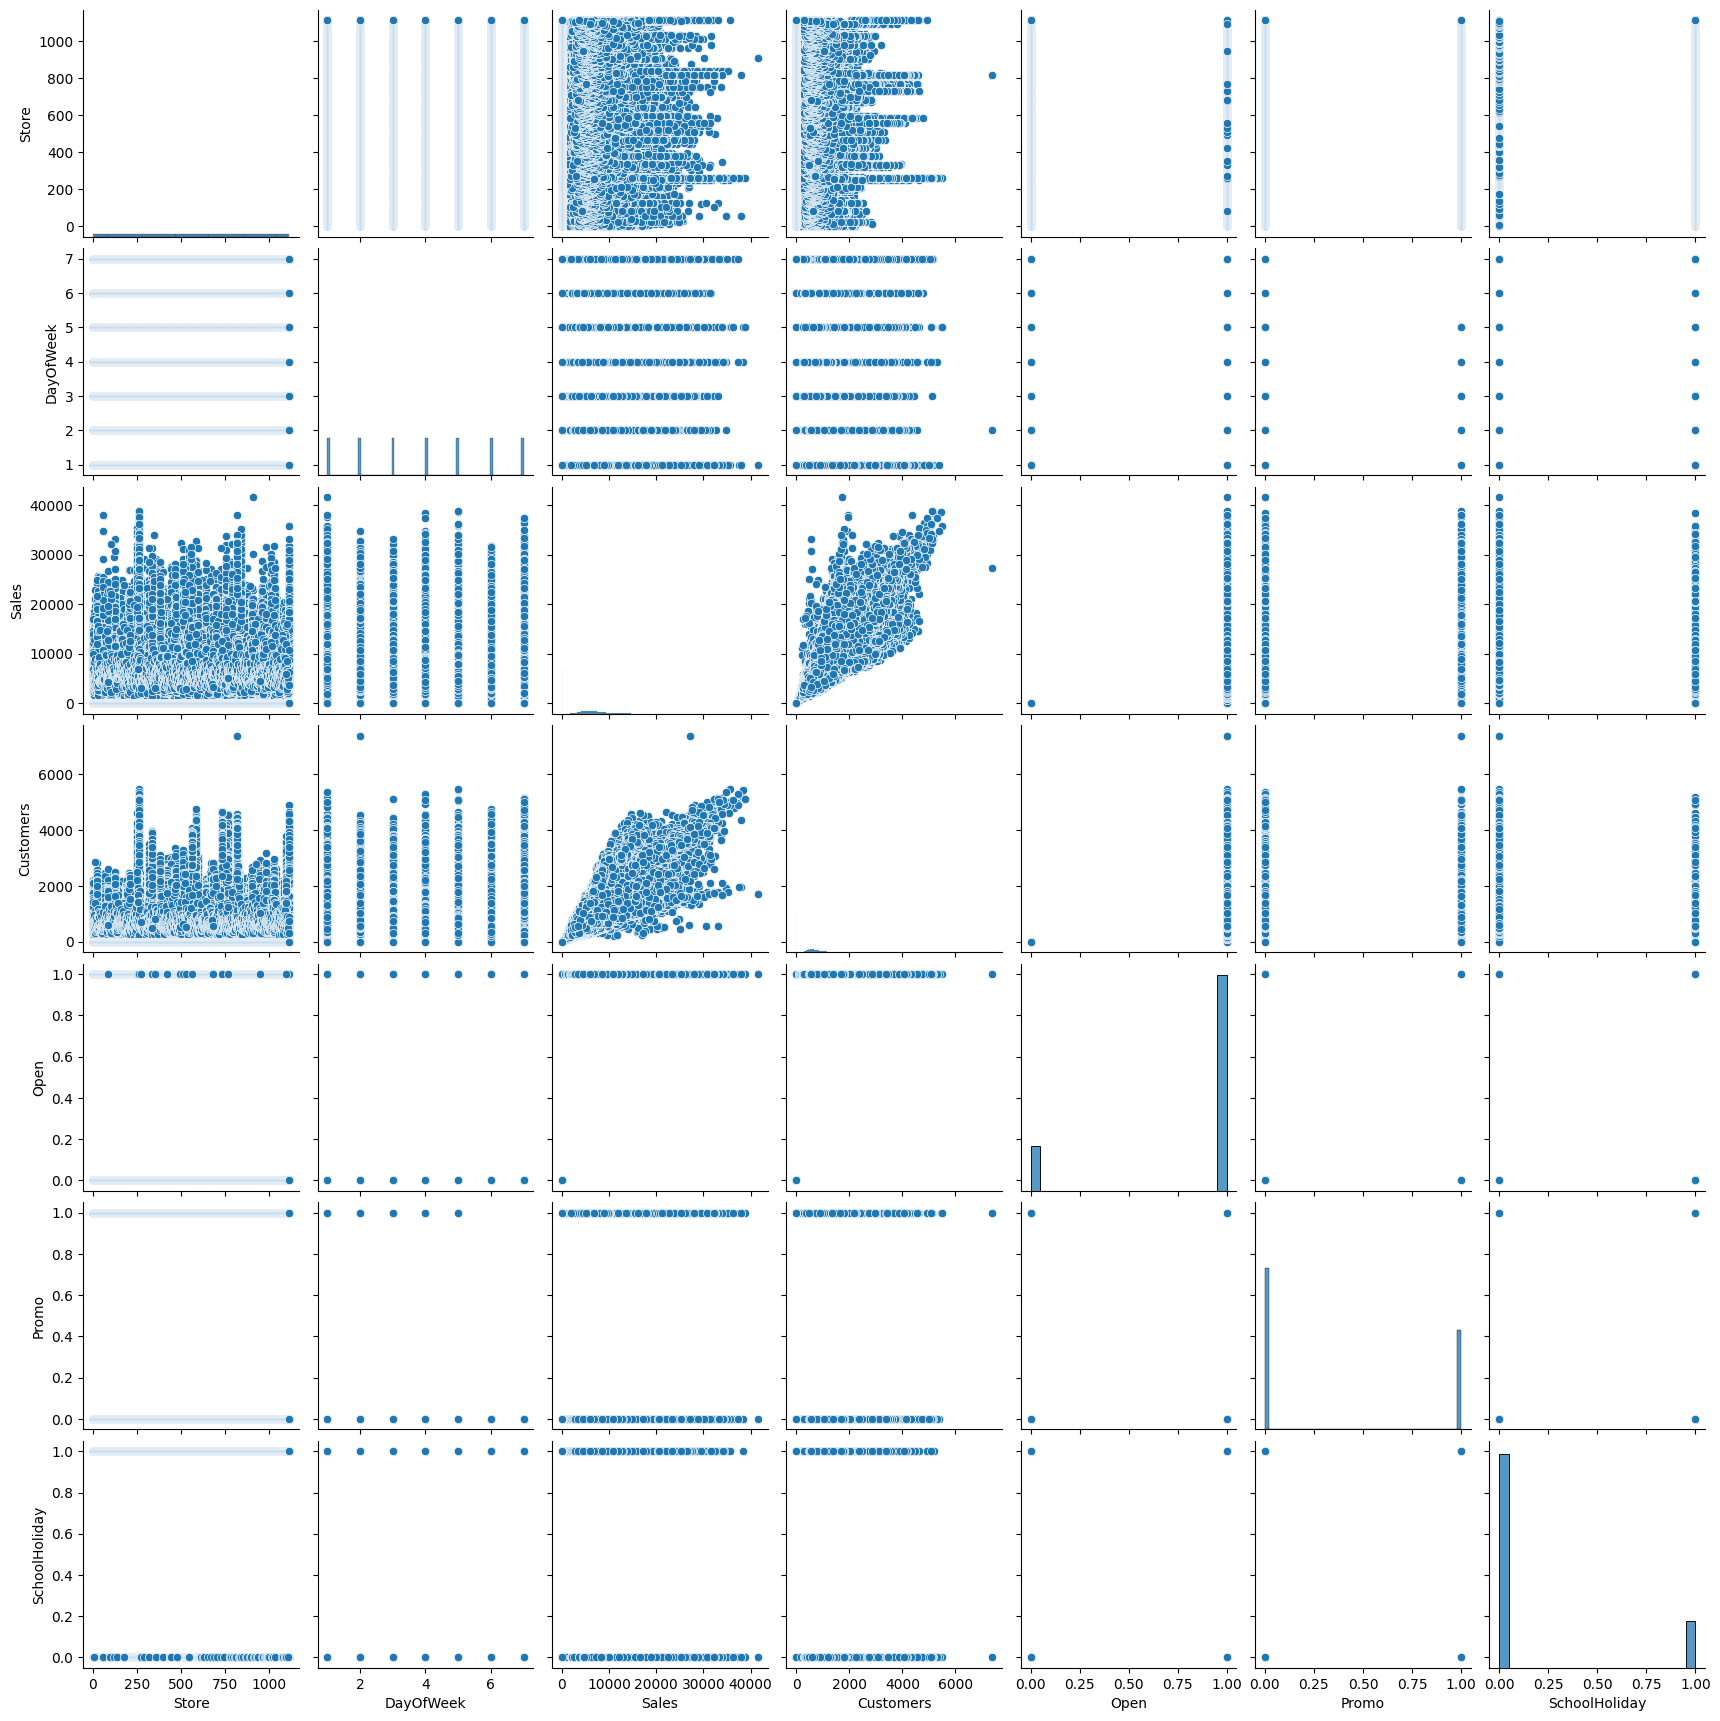

In [55]:
# Univariate, Bivariate & Multivariate Analysis of Categorical Features in Train DataFrame
sns.pairplot(train_df)

<Figure size 1000x600 with 0 Axes>

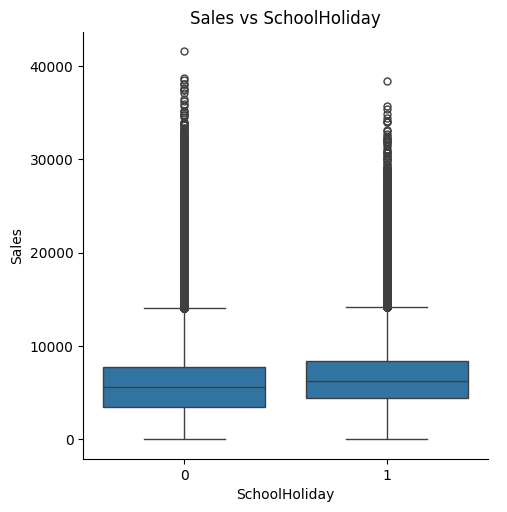

In [56]:
# Categorical Plot for Sales vs SchoolHoliday
plt.figure(figsize=(10, 6))
sns.catplot(x='SchoolHoliday', y='Sales', data=train_df, kind='box')
plt.title('Sales vs SchoolHoliday')
plt.show()

<Figure size 800x500 with 0 Axes>

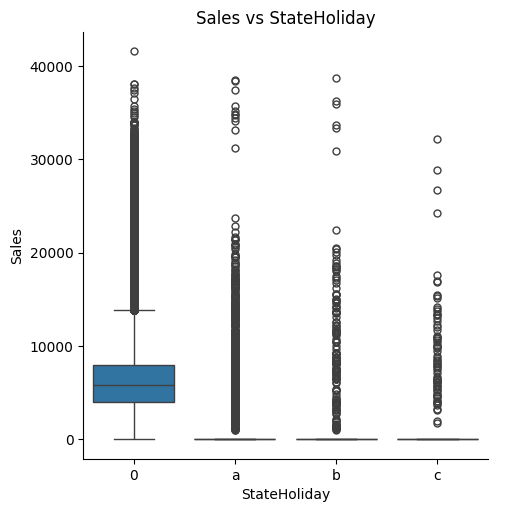

In [57]:
# Categorical Plot for Sales vs StateHoliday
plt.figure(figsize=(8, 5))
sns.catplot(x='StateHoliday', y='Sales', data=train_df, kind='box')
plt.title('Sales vs StateHoliday')
plt.show()

C:\Users\nikun\AppData\Local\Temp\ipykernel_7900\659650788.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(train_df['Customers'], train_df['Sales'], alpha=0.5, cmap='viridis')


Text(0.5, 1.0, 'Scatter Plot of Sales vs Customers')

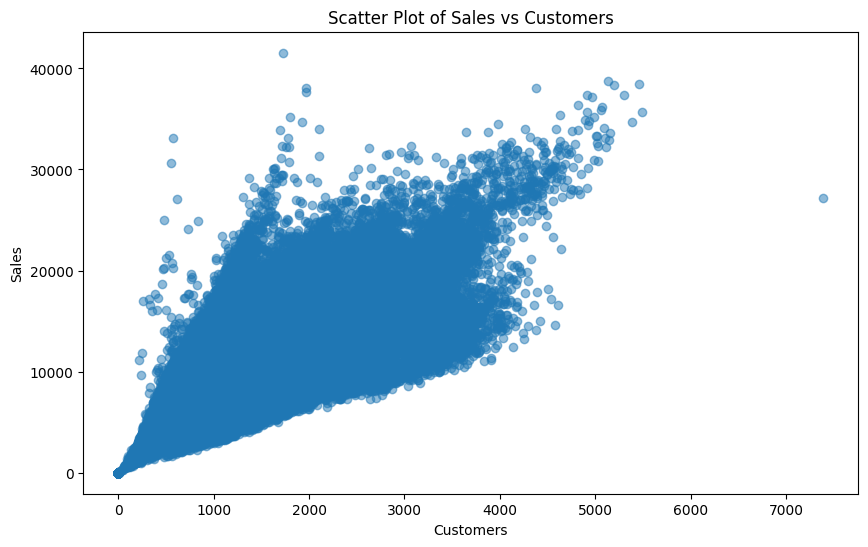

In [58]:
# Scatter Plot for Sales vs Customers
plt.figure(figsize=(10, 6))
plt.scatter(train_df['Customers'], train_df['Sales'], alpha=0.5, cmap='viridis')
plt.xlabel('Customers')
plt.ylabel('Sales')
plt.title('Scatter Plot of Sales vs Customers')

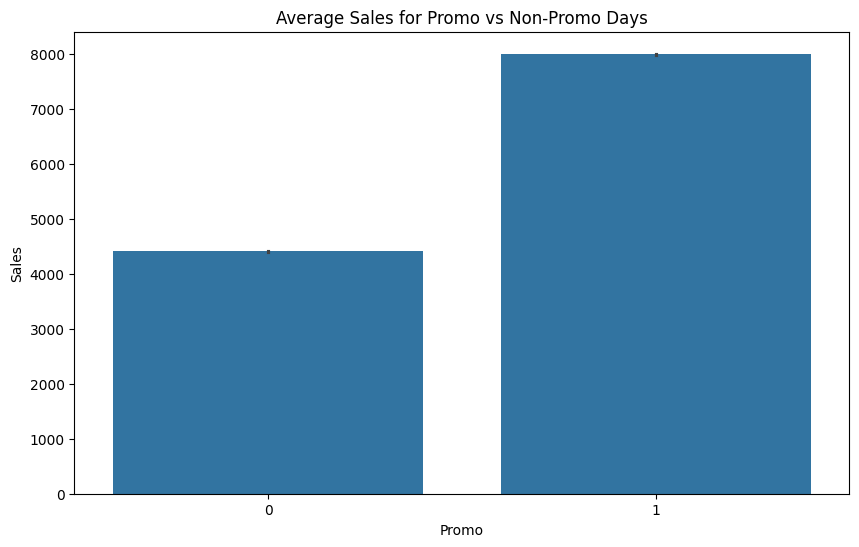

In [59]:
# Plotting Average Sales for Promo vs Non-Promo Days
plt.figure(figsize=(10, 6))
sns.barplot(x='Promo', y='Sales', data=train_df)
plt.title('Average Sales for Promo vs Non-Promo Days')
plt.show()

In [60]:
# Segregating Date into Day, Month and Year for Train DataFrame
train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df['Year'] = train_df['Date'].dt.year
train_df['Month'] = train_df['Date'].dt.month
train_df['Day'] = train_df['Date'].dt.day

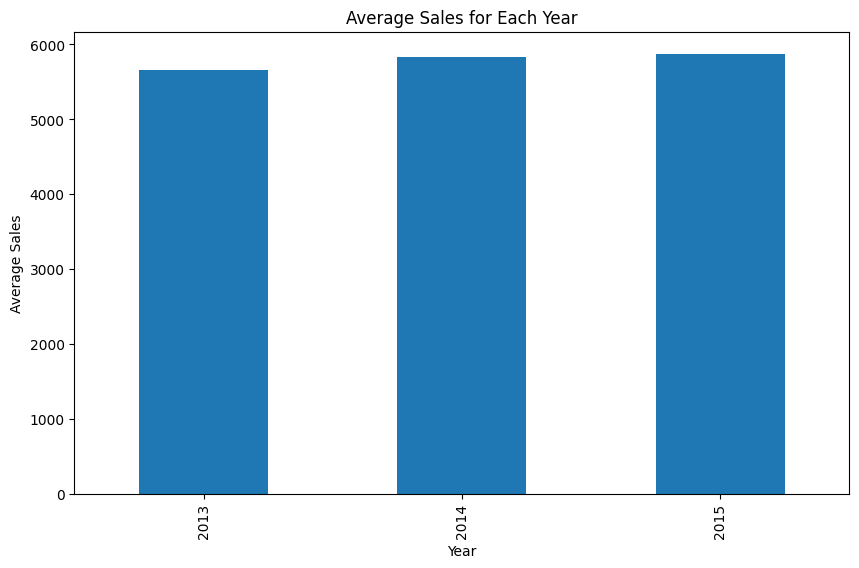

In [61]:
# Plotting Average Sales for Each Year
train_df.groupby('Year')['Sales'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('Average Sales for Each Year')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.show()

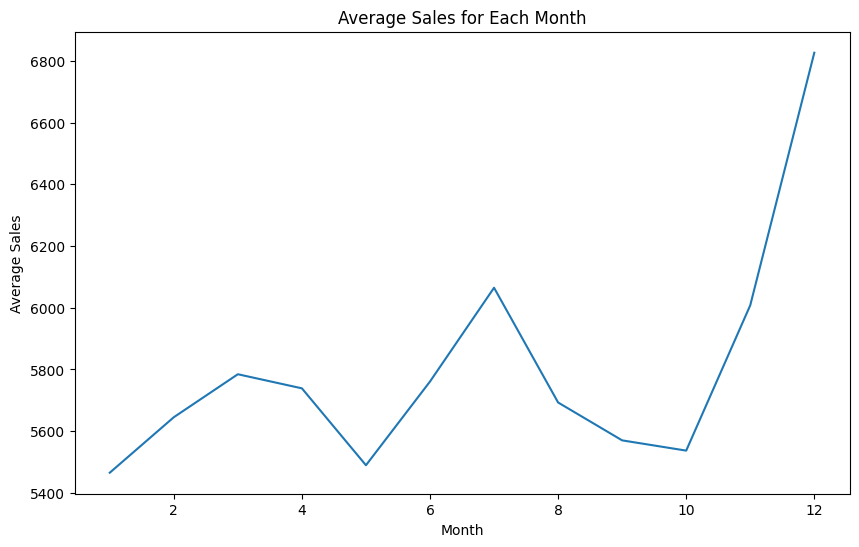

In [62]:
# Plotting Average Sales for Each Month
train_df.groupby('Month')['Sales'].mean().plot(kind='line', figsize=(10, 6))
plt.title('Average Sales for Each Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

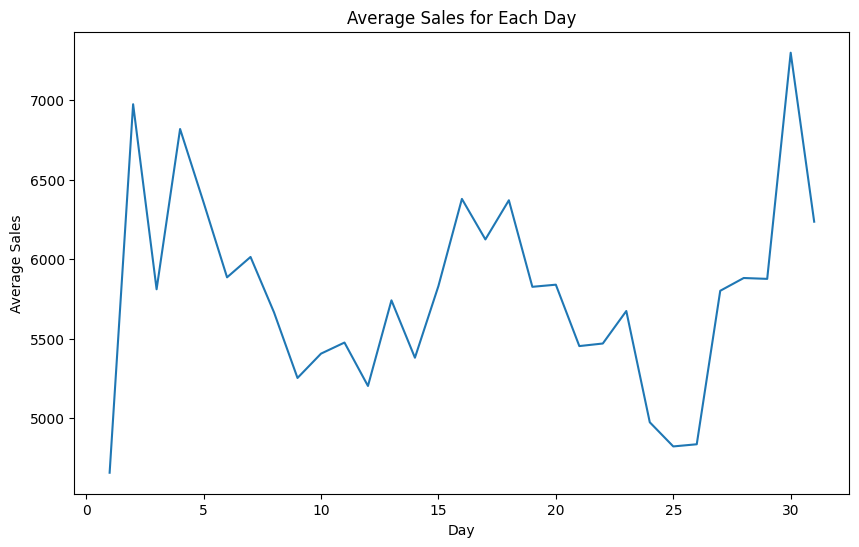

In [63]:
# Plotting Average Sales for Each Day
train_df.groupby('Day')['Sales'].mean().plot(kind='line', figsize=(10, 6))
plt.title('Average Sales for Each Day')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.show()

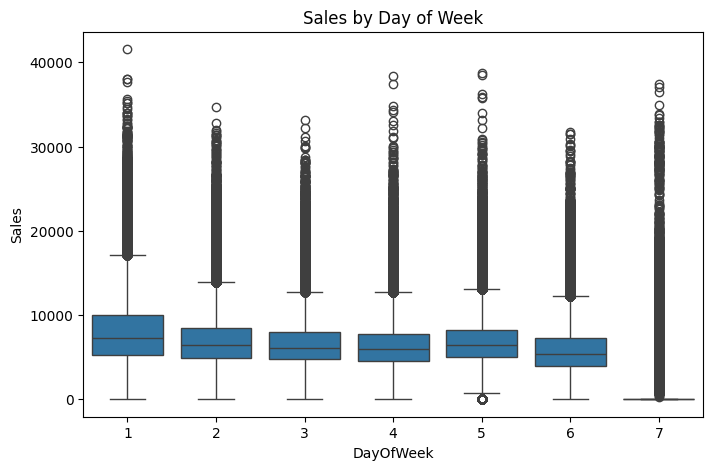

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


In [64]:
# Day of Week vs Sales Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x="DayOfWeek", y="Sales", data=train_df)
plt.title("Sales by Day of Week")
plt.show()

print(train_df.groupby("DayOfWeek")["Sales"].mean())

In [65]:
# Check the unique values in StateHoliday column
train_df['StateHoliday'] = train_df['StateHoliday'].astype(str)
train_df['StateHoliday'].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

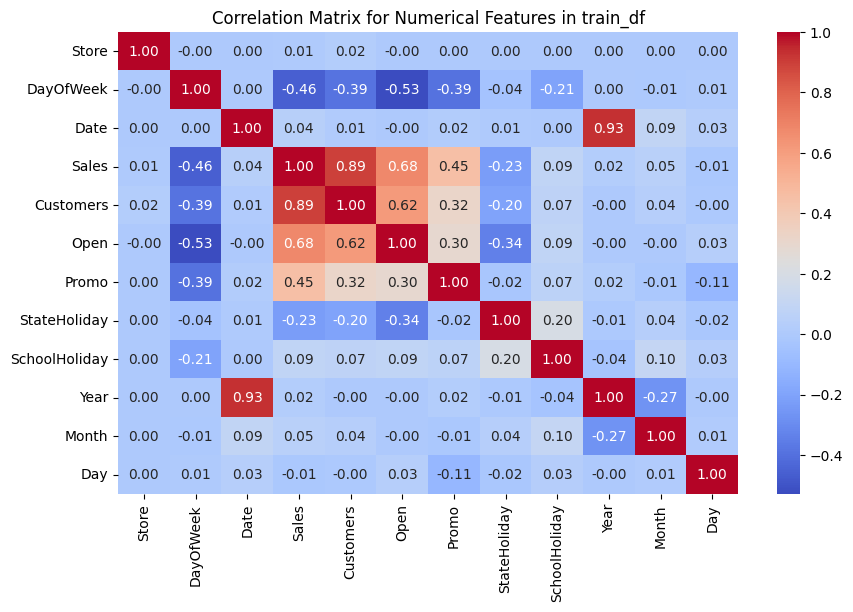

In [66]:
# Convert Unique Values in StateHoliday to Integers
state_holiday_mapping = {label: idx for idx, label in enumerate(train_df['StateHoliday'].unique())}
train_df['StateHoliday'] = train_df['StateHoliday'].map(state_holiday_mapping)
train_df['StateHoliday'] = train_df['StateHoliday'].astype('int')

# Correlation Matrix for Numerical Features in Train DataFrame
corr_matrix = train_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix for Numerical Features in train_df')
plt.show()

In [67]:
# Restore Categorical Nature of StateHoliday
train_df['StateHoliday'] = train_df['StateHoliday'].map({v: k for k, v in state_holiday_mapping.items()})
train_df['StateHoliday'] = train_df['StateHoliday'].astype(str)
train_df['StateHoliday'].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

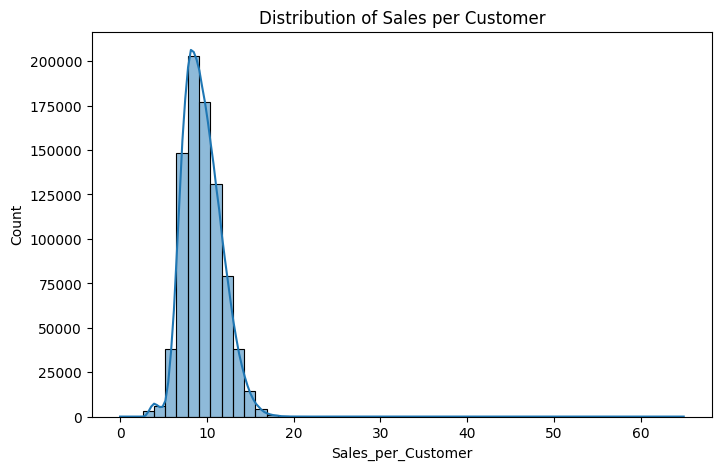

In [68]:
# Average Sales for Each Store
train_df['Sales_per_Customer'] = train_df['Sales'] / train_df['Customers']
plt.figure(figsize=(8,5))
sns.histplot(train_df['Sales_per_Customer'], bins=50, kde=True)
plt.title("Distribution of Sales per Customer")
plt.show()

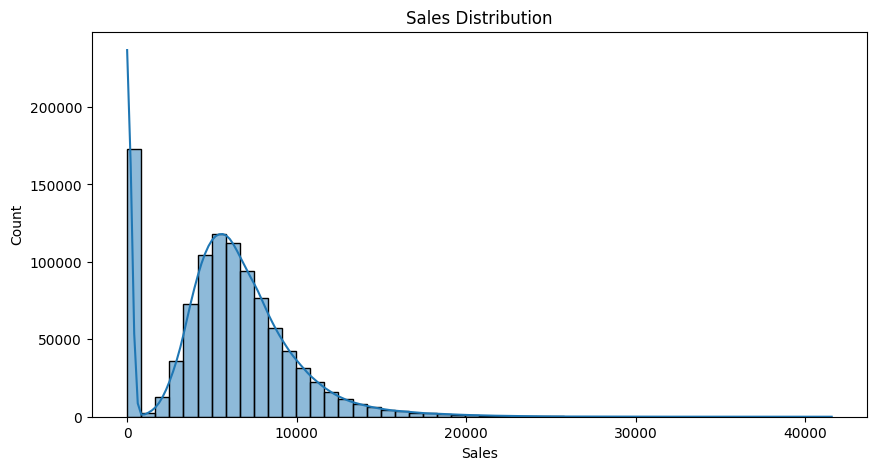

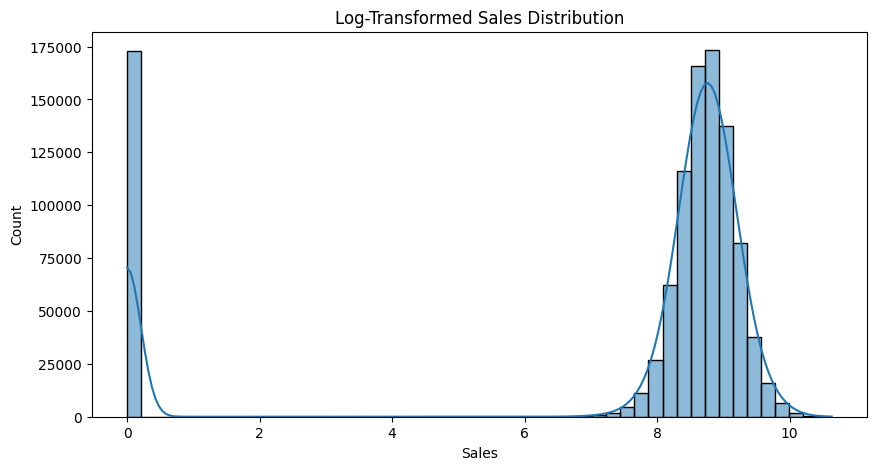

Skewness of Sales : 0.6414596158103787
Skewness of Customers : 1.5986502899508919


In [69]:
# Log Transformation of Sales Column to Reduce Skewness
plt.figure(figsize=(10,5))
sns.histplot(train_df["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(train_df["Sales"]), bins=50, kde=True)
plt.title("Log-Transformed Sales Distribution")
plt.show()

print("Skewness of Sales :", train_df["Sales"].skew())
print("Skewness of Customers :", train_df["Customers"].skew())

In [70]:
# Open vs Closed Days
print(train_df.loc[train_df["Open"]==0, "Sales"].unique())  # should be [0]
closed_pct = train_df[train_df["Open"]==0].shape[0] / len(train_df) * 100
print(f"Closed Days Percentage : {closed_pct:.2f}%")

[0]
Closed Days Percentage : 16.99%


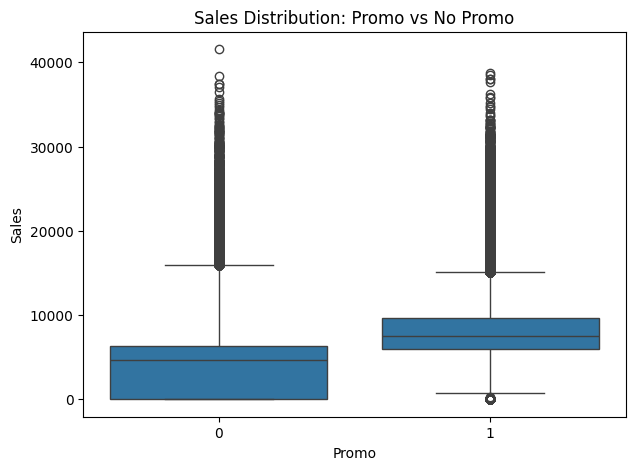

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [71]:
# Promo vs No Promo Sales Distribution
plt.figure(figsize=(7,5))
sns.boxplot(x="Promo", y="Sales", data=train_df)
plt.title("Sales Distribution: Promo vs No Promo")
plt.show()

print(train_df.groupby("Promo")["Sales"].mean())

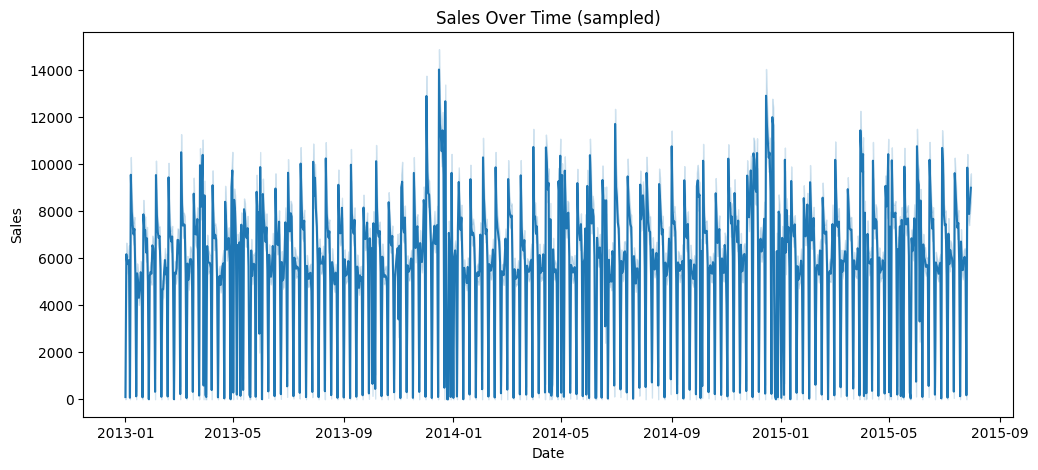

In [72]:
# Time-based Trends (using Date)
train_df["Date"] = pd.to_datetime(train_df["Date"])
plt.figure(figsize=(12,5))
sns.lineplot(x="Date", y="Sales", data=train_df.sample(100000))  # sample to reduce plotting time
plt.title("Sales Over Time (sampled)")
plt.show()

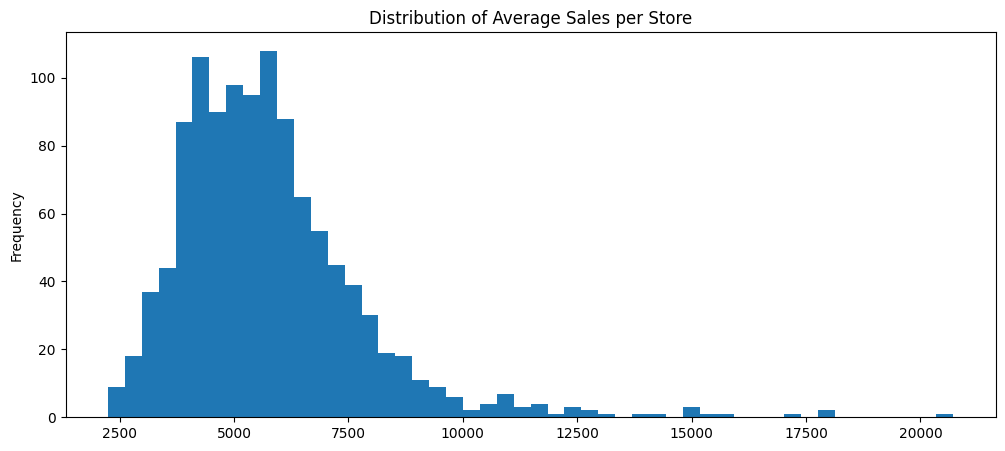

count     1115.000000
mean      5763.320541
std       2046.447377
min       2244.503185
25%       4412.415567
50%       5459.185775
75%       6633.871550
max      20718.515924
Name: Sales, dtype: float64


In [73]:
# Store-level Distribution of Average Sales
store_sales = train_df.groupby("Store")["Sales"].mean().sort_values()

plt.figure(figsize=(12,5))
store_sales.plot(kind="hist", bins=50)
plt.title("Distribution of Average Sales per Store")
plt.show()

print(store_sales.describe())

In [74]:
# Saving the Processed Train DataFrame
train_df.to_csv(os.path.join(PROCESSED_DATA_PATH, "train_eda_processed.csv"), index=False)

# 📌 Executive Summary of Train EDA  

### 1. Sales & Customers Distribution  
- **Sales distribution is right-skewed**: most transactions are in the lower-to-mid range, with fewer very high sales values.  
- **Customers strongly correlate with sales** (positive linear relationship), meaning customer count is a good predictor of revenue.  
- Some stores show higher sales variability, while others maintain consistent levels.  

### 2. Temporal Trends  
- **Weekly & Monthly Seasonality** observed:  
  - Sales peak during weekends and holidays.  
  - Strong spikes in **December** (Christmas season) and dips in summer months.  
- Clear **day-of-week pattern**:  
  - **Monday–Friday** sales are stable,  
  - **Saturday** shows higher peaks,  
  - **Sunday** is typically closed (sales = 0 for most stores).  

### 3. Promotional Impact  
- Stores running **Promo** campaigns consistently show higher sales.  
- **Promo effect is stronger on weekdays** than weekends.  
- Long-running promos (Promo2) amplify seasonality but do not always guarantee higher average sales across all stores.  

### 4. Store Performance Variation  
- Large performance variation exists **across store types and assortments**.  
- Some store types consistently outperform others regardless of competition distance.  
- **Outliers detected**: a few stores have unusually high sales compared to their peers.  

### 5. Competition Influence  
- Stores with **nearby competitors** generally report lower sales, while isolated stores benefit from less direct competition.  
- However, effect is not uniform → depends on store type and promo activity.  

---

## 🚀 Key Business Insights  
- **Seasonality is strong**: holidays and weekends significantly drive revenue.  
- **Promotions are effective**, especially for driving weekday traffic, but must be tailored by store type.  
- **Competition matters**, but store characteristics (assortment, type) mediate its impact.  
- **Customer count is the single strongest driver of sales** → modeling should prioritize customer-related variables.  
- Data requires **handling of closed days (Sunday = 0 sales)** separately from actual low-sales days.  

### Store Data - Exploratory Data Analysis

#### General Information

In [75]:
# Check the General Information about Store DataFrame
print(store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB
None


In [76]:
# Handle all the Missing Values in Store DataFrame

# Handle NaN Values in Store DataFrame - CompetitionDistance using Median
store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].median(), inplace=True)

# Handle NaN Values in Store DataFrame - CompetitionOpenSinceMonth using Mode
store_df['CompetitionOpenSinceMonth'].fillna(store_df['CompetitionOpenSinceMonth'].mode()[0], inplace=True)

# Handle NaN Values in Store DataFrame - CompetitionOpenSinceYear using Mode
store_df['CompetitionOpenSinceYear'].fillna(store_df['CompetitionOpenSinceYear'].mode()[0], inplace=True)

# Handle NaN Values in Store DataFrame - Promo2SinceWeek using Mode
store_df['Promo2SinceWeek'].fillna(store_df['Promo2SinceWeek'].mode()[0], inplace=True)

# Handle NaN Values in Store DataFrame - Promo2SinceYear using Mode
store_df['Promo2SinceYear'].fillna(store_df['Promo2SinceYear'].mode()[0], inplace=True)

# Handle NaN Values in Store DataFrame - PromoInterval using Mode
store_df['PromoInterval'].fillna(store_df['PromoInterval'].mode()[0], inplace=True)

# Check for Missing Values in Store DataFrame after Handling
missing_values_store = store_df.isnull().sum()
print("Missing Values per Column in store_df after Handling")
print(missing_values_store)
total_missing_store = store_df.isnull().sum().sum()
print(f"\nTotal Missing Values in store_df after Handling : {total_missing_store}")

Missing Values per Column in store_df after Handling
Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

Total Missing Values in store_df after Handling : 0


C:\Users\nikun\AppData\Local\Temp\ipykernel_7900\1867049402.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].median(), inplace=True)
C:\Users\nikun\AppData\Local\Temp\ipykernel_7900\1867049402.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

In [77]:
# Check for Duplicates in Store DataFrame
duplicates = store_df.duplicated().sum()
print(f"Total Duplicates in store_df : {duplicates}")

Total Duplicates in store_df : 0


#### Univariate Analysis

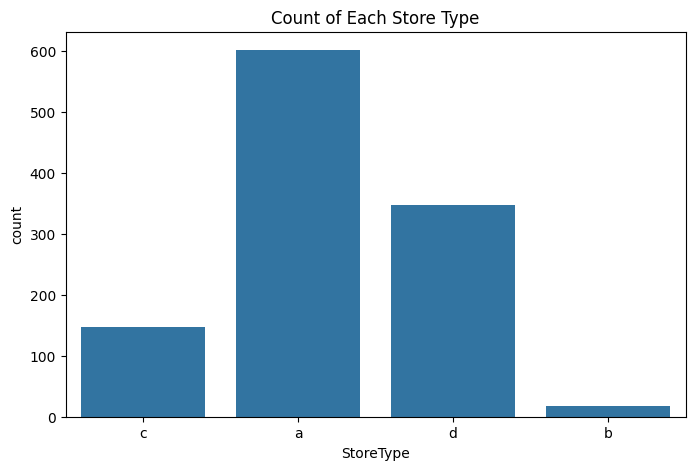

In [78]:
# Display Count of Each Store Type
plt.figure(figsize=(8,5))
sns.countplot(x='StoreType', data=store_df)
plt.title('Count of Each Store Type')
plt.show()

# 🔎 Interpretation: Most stores belong to one or two dominant types.
# Useful to check which types drive most sales later.

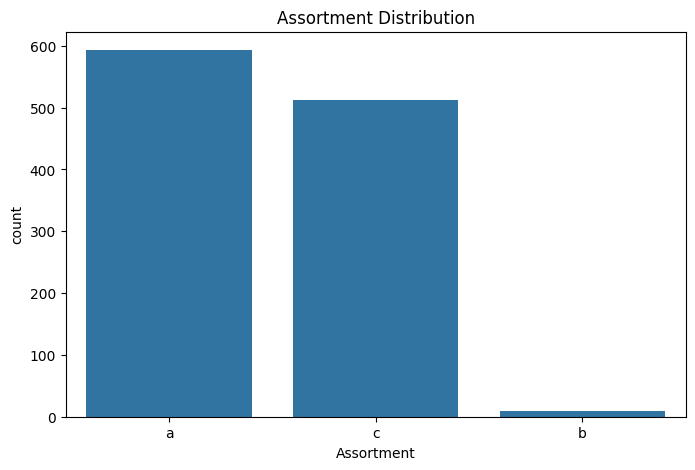

In [79]:
# Display Count for Assortment in Basic/Extra/Extended per Promo2
plt.figure(figsize=(8,5))
sns.countplot(x='Assortment', data=store_df)
plt.title('Assortment Distribution')
plt.show()

# 🔎 Interpretation: Majority of stores follow one assortment strategy (Basic/Extra/Extended).
# Helps identify if assortment correlates with performance.

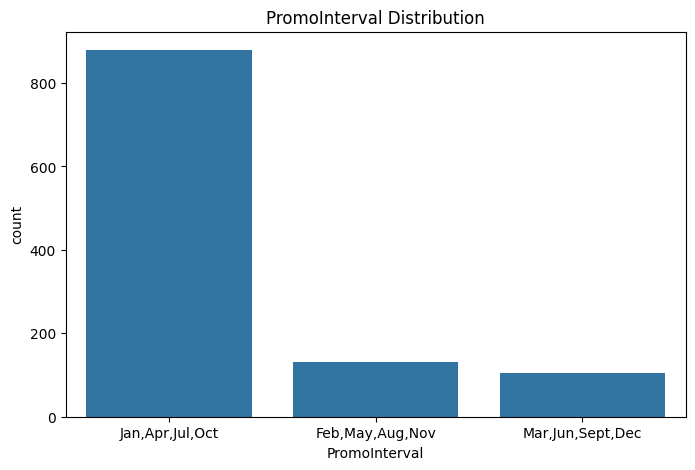

In [80]:
# Display Distribution of PromoInterval
plt.figure(figsize=(8,5))
sns.countplot(x='PromoInterval', data=store_df)
plt.title('PromoInterval Distribution')
plt.show()

# 🔎 Interpretation: Promo intervals are skewed; some months are more common for promos.

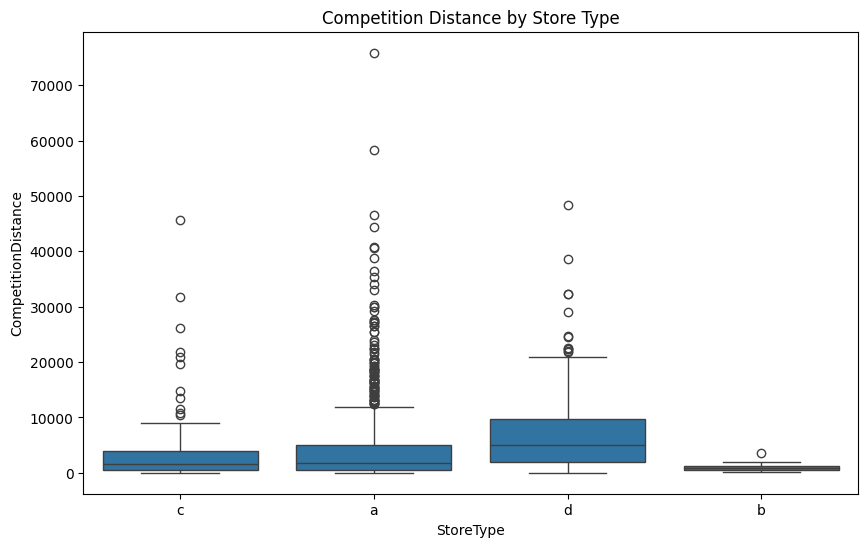

In [81]:
# Create Scatter Plot for CompetitionDistance vs StoreType
plt.figure(figsize=(10,6))
sns.boxplot(x='StoreType', y='CompetitionDistance', data=store_df)
plt.title('Competition Distance by Store Type')
plt.show()

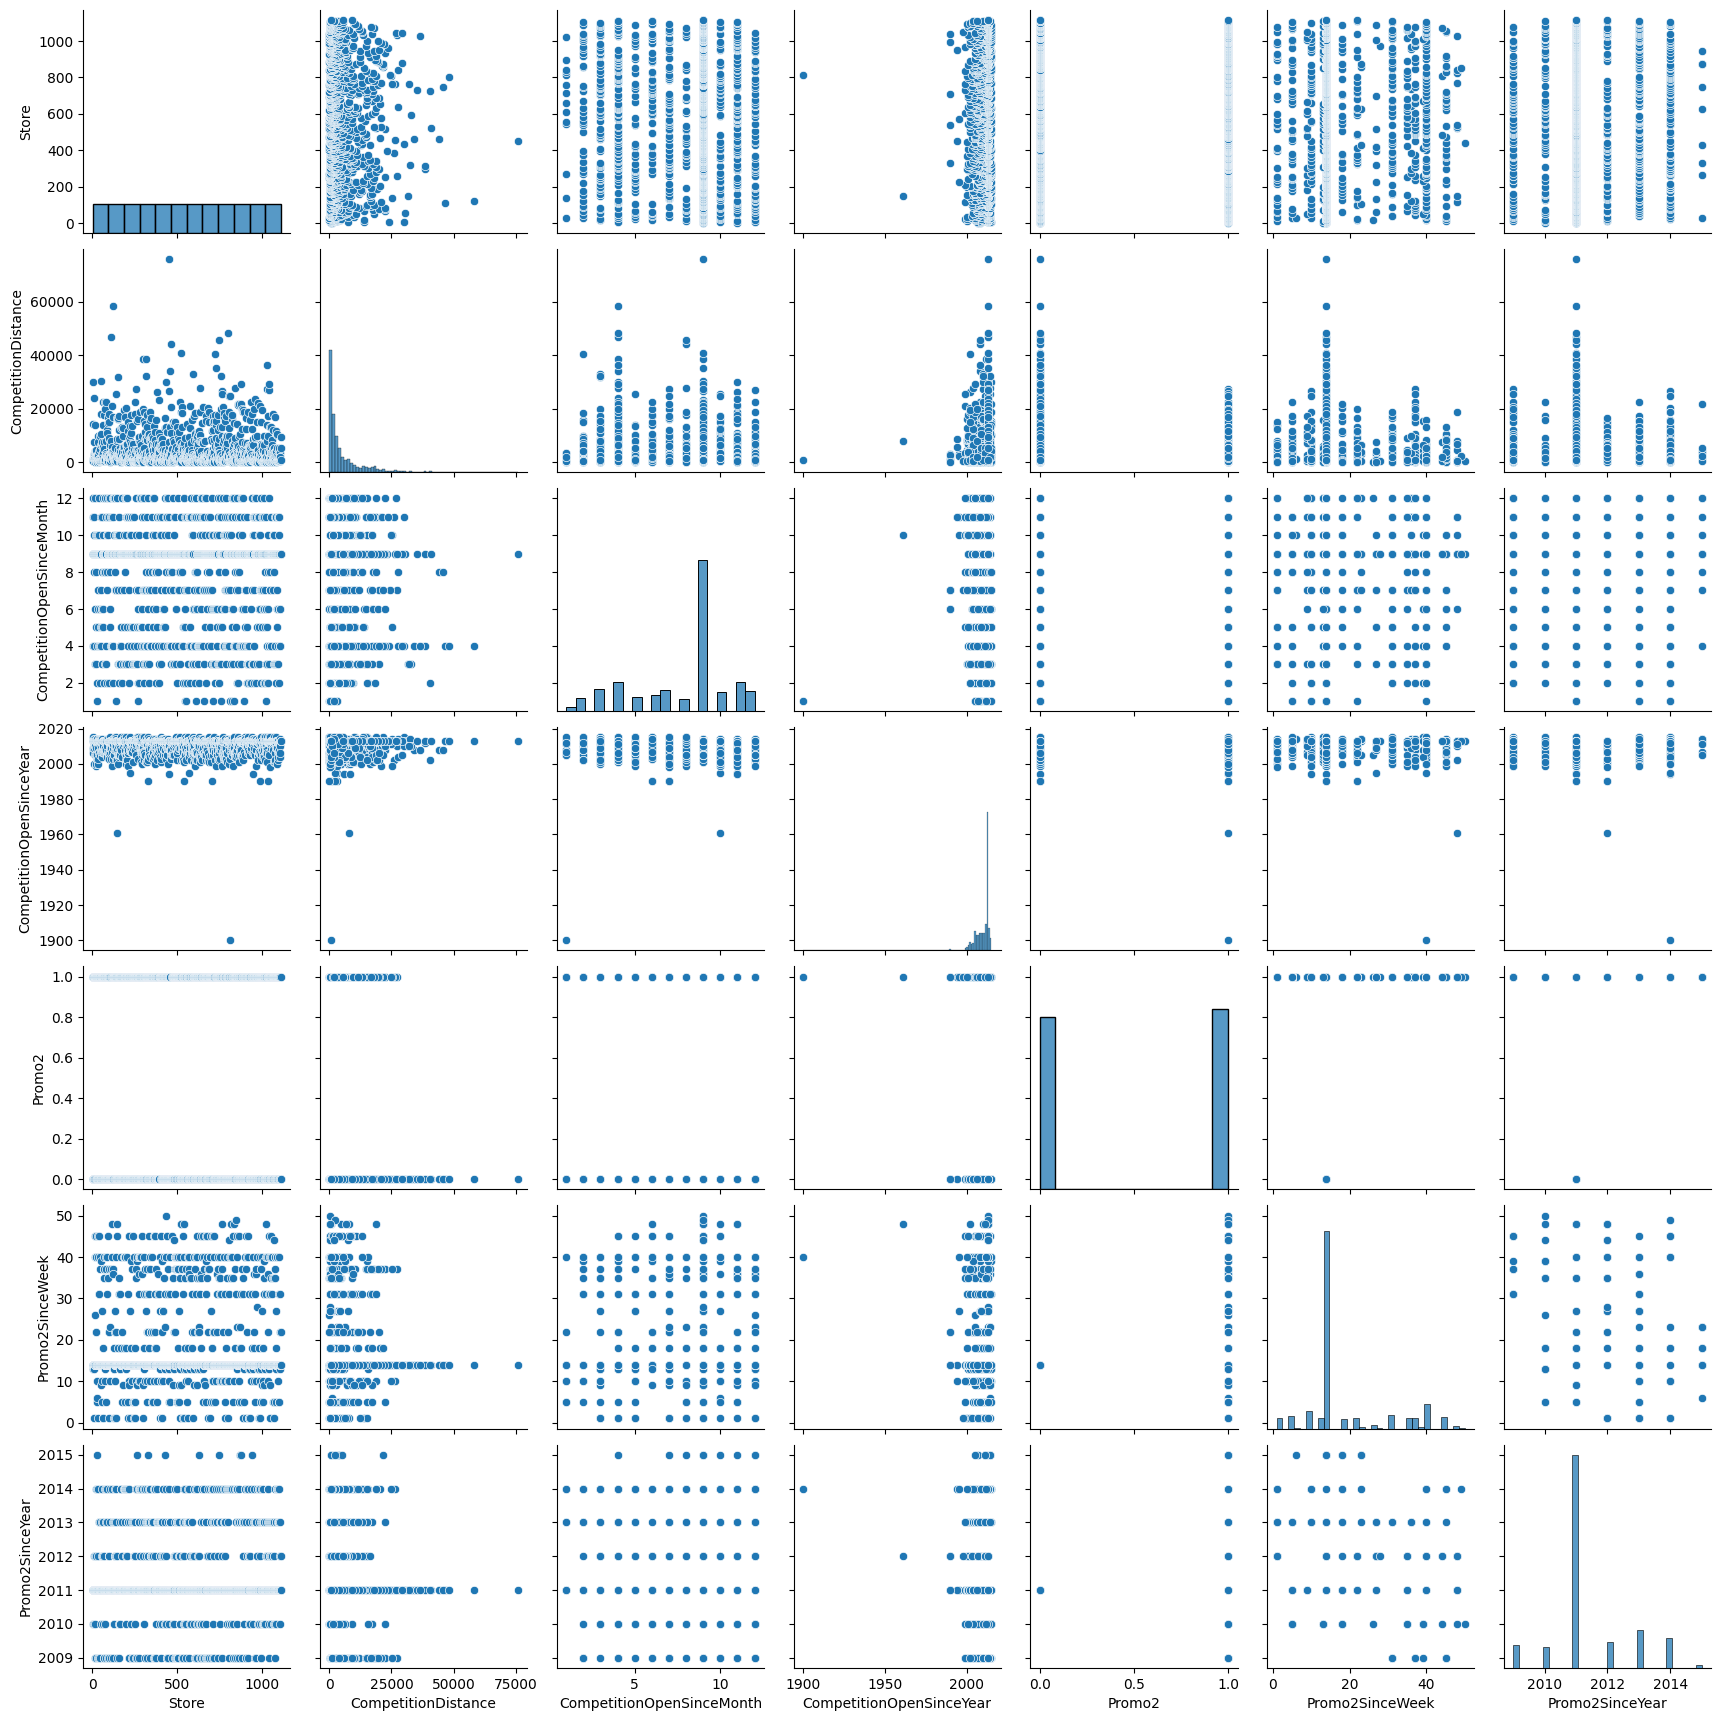

In [82]:
# Univariate, Bivariate & Multivariate Analysis of Categorical Features in Store DataFrame
sns.pairplot(store_df)

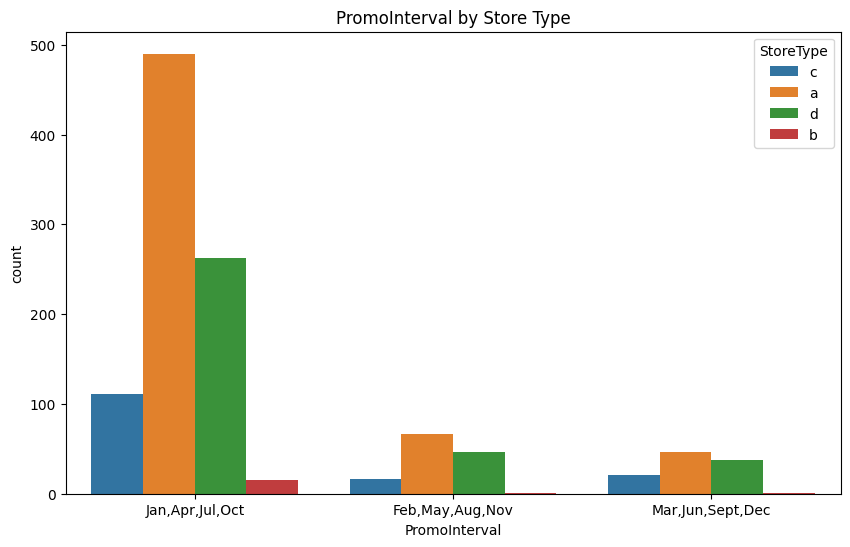

In [83]:
# Display Relationship between Promotional Interval and Store Type
plt.figure(figsize=(10,6))
sns.countplot(x='PromoInterval', hue='StoreType', data=store_df)
plt.title('PromoInterval by Store Type')
plt.show()

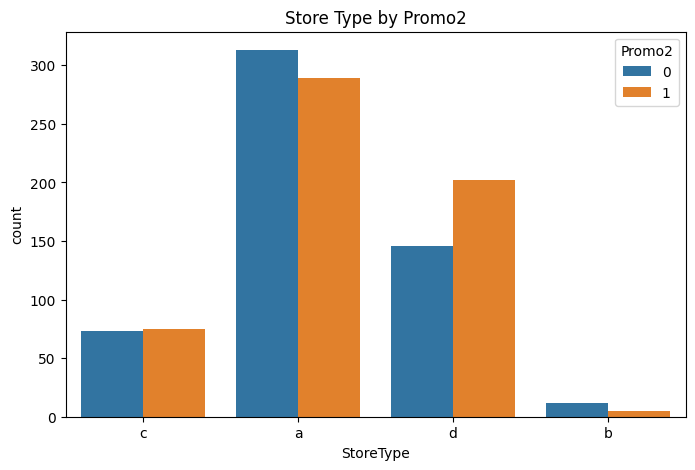

In [84]:
# Check for Relationship between Store & Promo2
plt.figure(figsize=(8,5))
sns.countplot(x='StoreType', hue='Promo2', data=store_df)
plt.title('Store Type by Promo2')
plt.show()

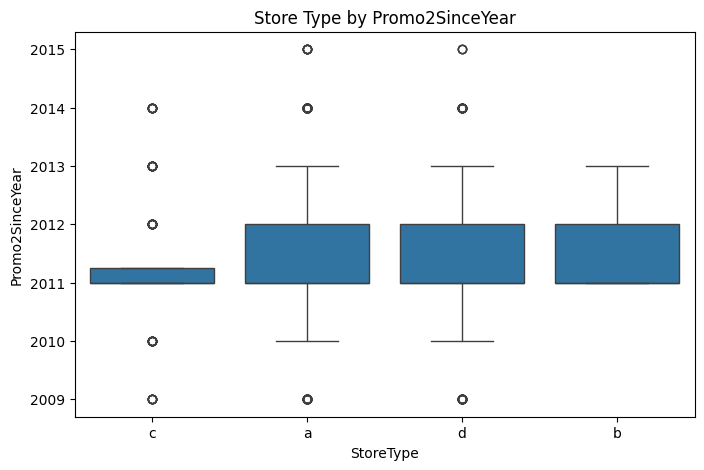

In [85]:
# Plot StoreType vs Promo2SinceYear
plt.figure(figsize=(8,5))
sns.boxplot(x='StoreType', y='Promo2SinceYear', data=store_df)
plt.title('Store Type by Promo2SinceYear')
plt.show()

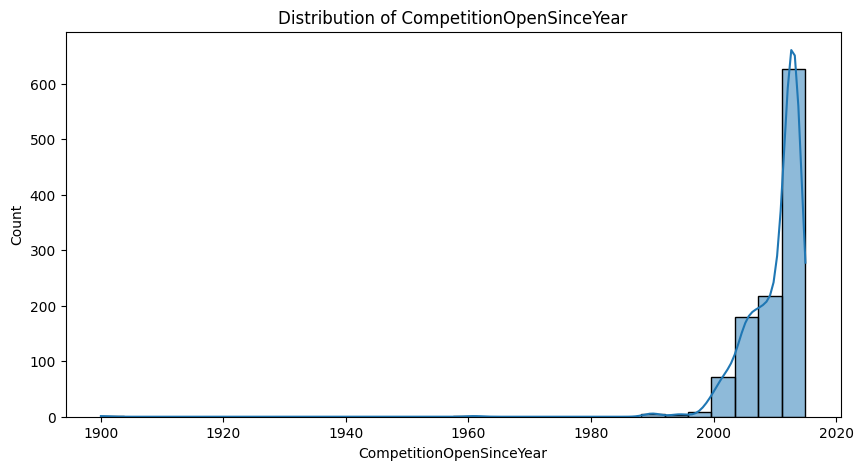

In [86]:
# Check Distribution of CompetitionOpenSinceYear
plt.figure(figsize=(10,5))
sns.histplot(store_df['CompetitionOpenSinceYear'], bins=30, kde=True)
plt.title('Distribution of CompetitionOpenSinceYear')
plt.show()

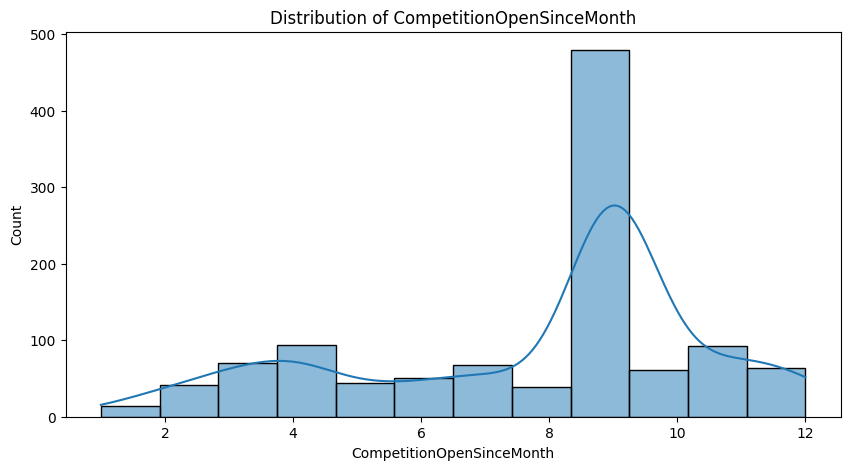

In [87]:
# Check Distribution of CompetitionOpenSinceMonth
plt.figure(figsize=(10,5))
sns.histplot(store_df['CompetitionOpenSinceMonth'], bins=12, kde=True)
plt.title('Distribution of CompetitionOpenSinceMonth')
plt.show()

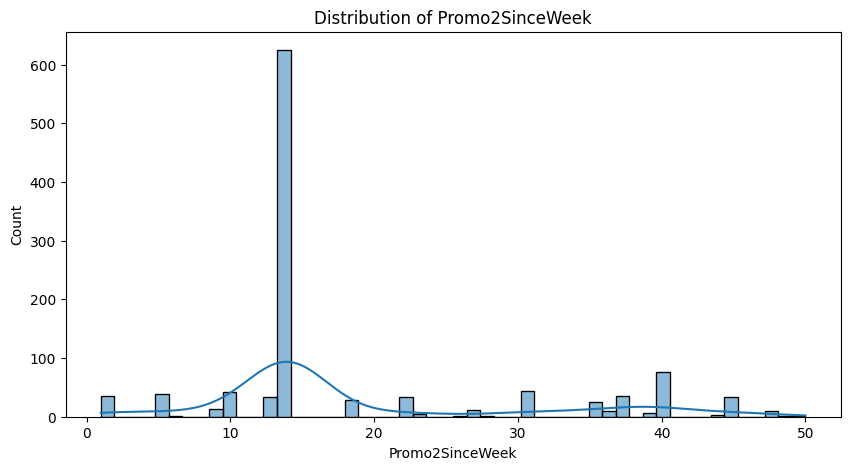

In [88]:
# Check Distribution of Promo2SinceWeek
plt.figure(figsize=(10,5))
sns.histplot(store_df['Promo2SinceWeek'], bins=52, kde=True)
plt.title('Distribution of Promo2SinceWeek')
plt.show()

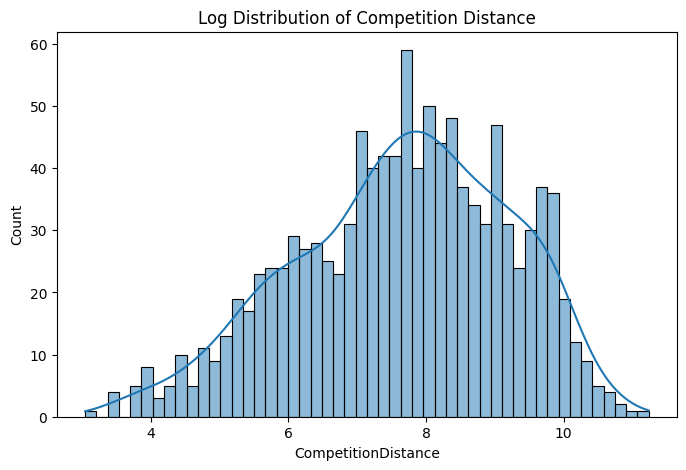

Skewness of CompetitionDistance : 2.9343886626294093


In [89]:
# Log Data Transformation of CompetitionDistance to Reduce Skewness
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(store_df['CompetitionDistance']), bins=50, kde=True)
plt.title("Log Distribution of Competition Distance")
plt.show()
print("Skewness of CompetitionDistance :", store_df["CompetitionDistance"].skew())
store_df["CompetitionDistance"] = np.log1p(store_df["CompetitionDistance"])

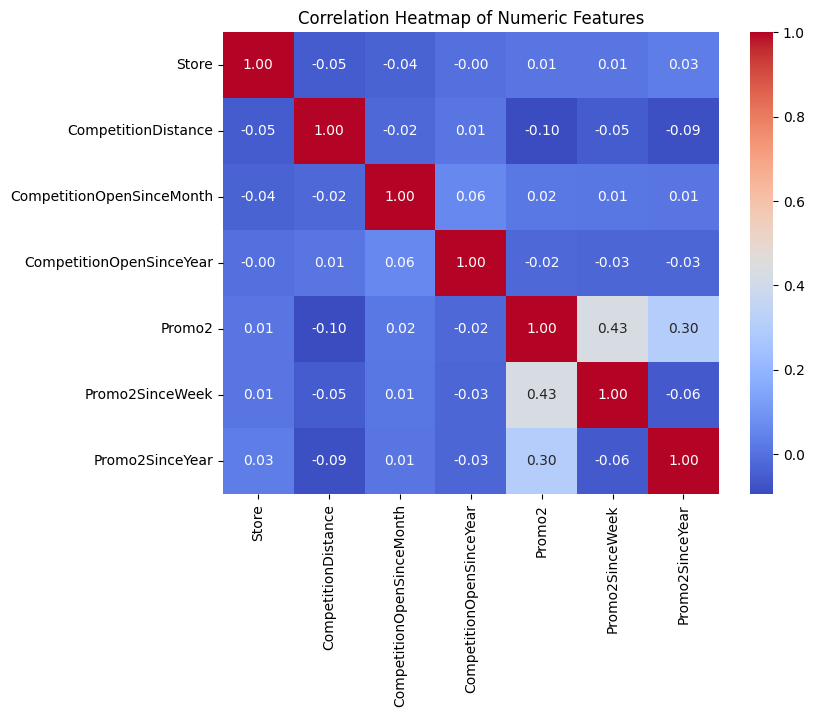

In [90]:
# Correlation Heatmap of Numeric Features
plt.figure(figsize=(8,6))
sns.heatmap(store_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [91]:
# Display Crosstab between StoreType, Assortment and Promo2
print(pd.crosstab(store_df['StoreType'], store_df['Assortment']))
print('\n')
print(pd.crosstab(store_df['StoreType'], store_df['Promo2']))

Assortment    a  b    c
StoreType              
a           381  0  221
b             7  9    1
c            77  0   71
d           128  0  220


Promo2       0    1
StoreType          
a          313  289
b           12    5
c           73   75
d          146  202


In [92]:
# Saving the Processed Store DataFrame
store_df.to_csv(os.path.join(PROCESSED_DATA_PATH, "store_eda_processed.csv"), index=False)

# 📌 Executive Summary of Store EDA  

### 1. Store Types & Assortments  
- Majority of stores belong to **1–2 dominant types**, meaning sales contribution may be heavily skewed towards these.  
- Most stores follow a **basic assortment strategy**, with fewer adopting extended/extra.  
- Cross-tabs show that assortment choice often depends on store type.  

### 2. Promotional Strategies  
- **Promo2** is not universally adopted — its usage varies strongly by **store type** and **assortment**.  
- Promo2 adoption became more common **after 2009**, with many stores starting campaigns in the **early weeks of the year**.  
- Some store types align more with specific **promo intervals**, indicating strategic promo timing differences.  

### 3. Competition Landscape  
- **CompetitionDistance** is highly skewed — most stores have competitors nearby, while a few face extremely distant competition.  
- After log transformation, the data is more balanced for analysis.  
- Most competitors opened stores **post-2000**, showing the market became denser in the last two decades.  
- Competition opening months are evenly distributed → no seasonality in store openings.  

### 4. Feature Relationships  
- Weak correlations among numeric features → suggests that **store characteristics are independent**.  
- Strong patterns are observed in categorical cross-tabs (e.g., certain store types almost always linked to specific assortments and promo strategies).  

---

## 🚀 Key Business Insights
- **Store strategy segmentation** is evident:  
  - Certain store types drive most promos, while others rely on stable assortments.  
- **Promo2 is a differentiator**: Not all stores use it, but those that do follow specific intervals — could impact sales seasonality.  
- **Competition pressure is uneven**: Some stores are surrounded by nearby competitors, while others are relatively isolated — may influence performance differently.  
- **Data quality**: Skewness in numeric fields (esp. competition distance) required log-transform, which improves downstream modeling.  